In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_behavior.csv')
df.head()


,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [ ]:
#What is the average, median, and mode of PurchaseAmount?
purchase_mean = df["PurchaseAmount"].mean()
purchase_median = df["PurchaseAmount"].median()
purchase_mode = df["PurchaseAmount"].mode()[0]

print("Average Purchase Amount:", purchase_mean)
print("Median Purchase Amount:", purchase_median)
print("Mode Purchase Amount:", purchase_mode)

Average Purchase Amount: 1003.9506701030928
Median Purchase Amount: 998.0799999999999
Mode Purchase Amount: 0.0


In [ ]:
df["PurchaseAmount"] = df["PurchaseAmount"].fillna(purchase_mean)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   5000 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [ ]:
from scipy.stats import zscore

# outlayer  plot display checks
def outlier_display(df, column):
  plots = [sns.boxplot,sns.stripplot,sns.swarmplot]
  for p in plots:
    p(x="PurchaseAmount", data=df)
    plt.show()

# IQR outlayer  removers  method
def IQR_outliers_removel(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  #IQR
  IQR = Q3 - Q1
  #Lower and Upper Boundaries
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  no_outliers = df[(df[column] >= lower) & (df[column] <= upper)]
  outlier_display(no_outliers, column)
  return no_outliers

# percental outlayer  removers  method
def Percent_outliers_removel(df, column):
  #Percentiles
  P5 = np.percentile(df['PurchaseAmount'], 5)
  P95 = np.percentile(df['PurchaseAmount'], 95)
  no_outliers = df[(df[column] >= P5) & (df[column] <= P95)]
  outlier_display(no_outliers, column)
  return no_outliers

#z score outlayer  removers  method
def z_score_outliers_removel(df, column):
  df['z_score'] = zscore(df['PurchaseAmount'])
  no_outliers =  df[df['z_score'].abs() <= 2]
  outlier_display(no_outliers, column)
  return no_outliers

#outliers_removel(df, "PurchaseAmount")

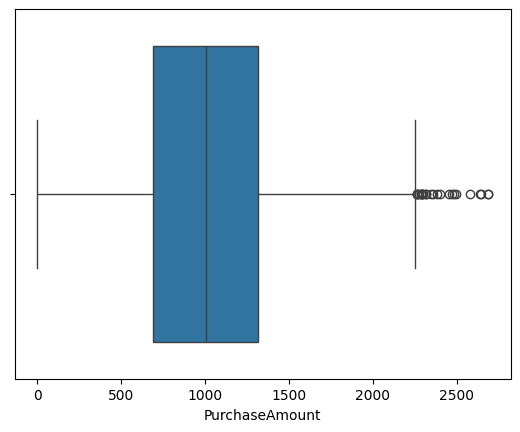

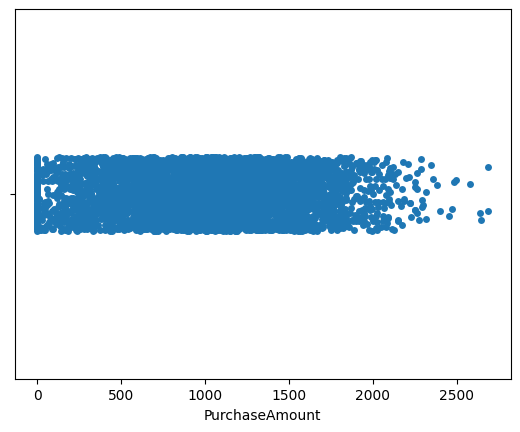

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 58.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


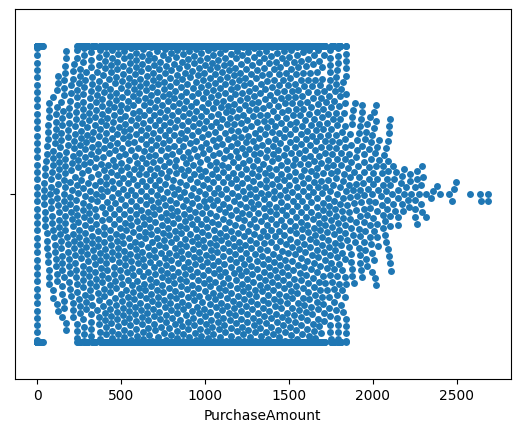

In [ ]:
outlier_display(df, "PurchaseAmount")

In [ ]:
#yes their is an outliersbetweeen 2000 and 2500

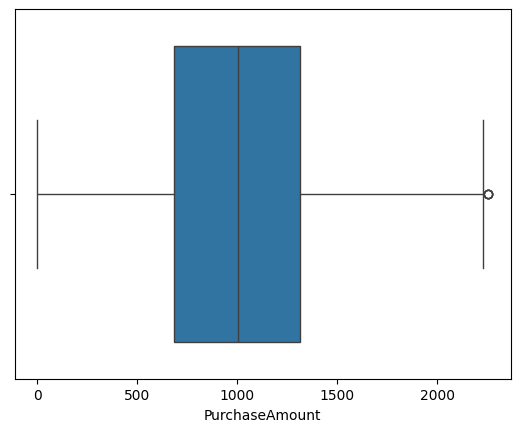

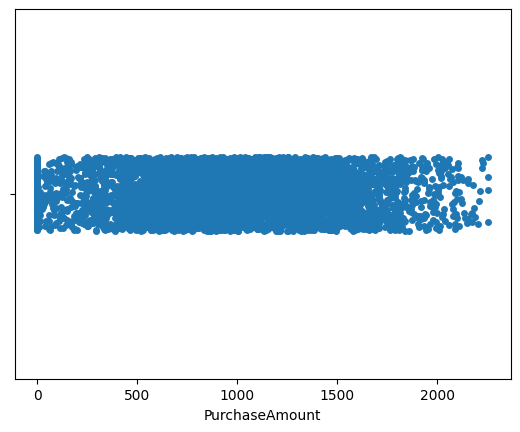

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 53.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


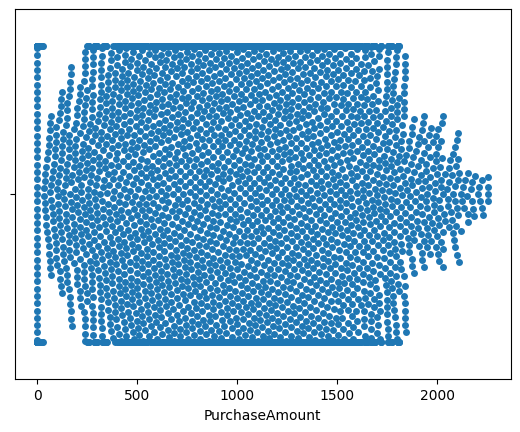

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07000,Fashion,No,A
1,1002,Female,South,1003.95067,Electronics,Yes,B
2,1003,Female,West,1194.41000,Fashion,No,A
3,1004,Female,South,413.06000,Grocery,No,A
4,1005,Male,West,1556.32000,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00000,Electronics,Yes,B
4996,5997,Male,West,978.87000,Fashion,Yes,A
4997,5998,Male,West,906.93000,Fashion,No,NaN
4998,5999,Female,South,375.67000,Fashion,No,NaN


In [ ]:
IQR_outliers_removel(df, "PurchaseAmount")

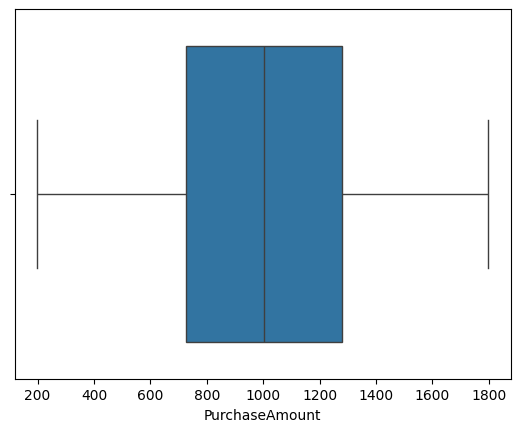

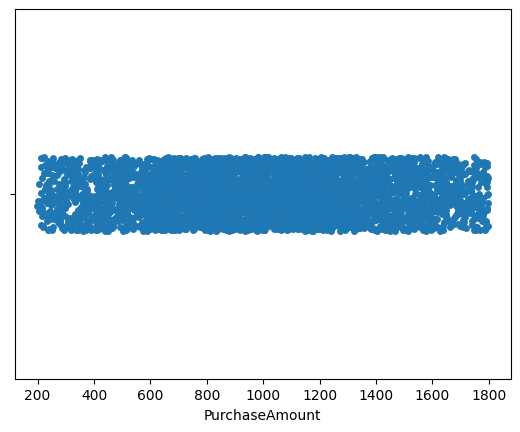

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


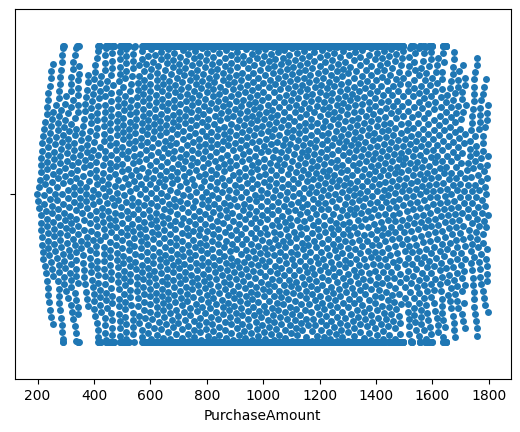

In [ ]:
clean_df = Percent_outliers_removel(df, "PurchaseAmount")

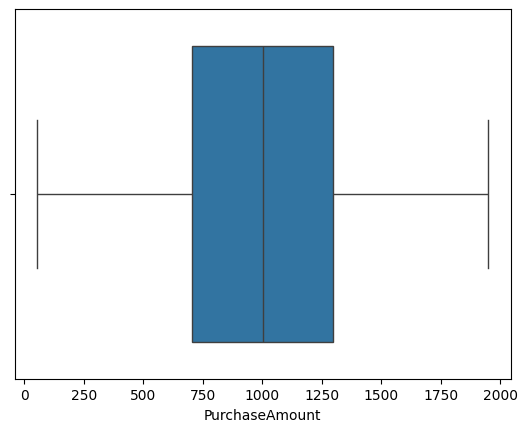

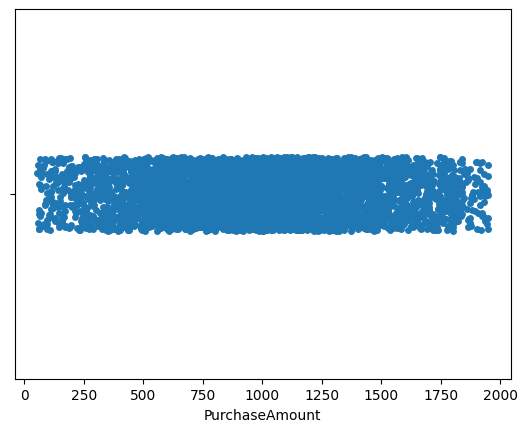

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 46.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


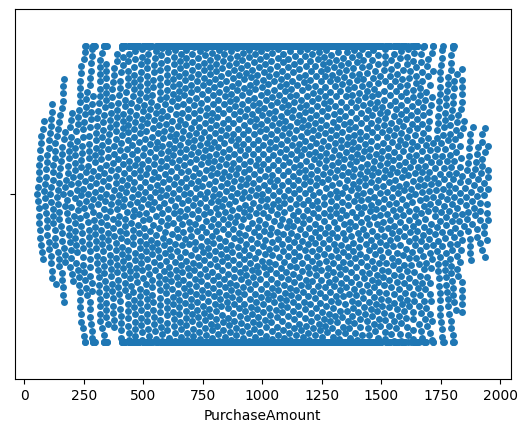

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup,z_score
0,1001,Male,South,256.07000,Fashion,No,A,-1.575224e+00
1,1002,Female,South,1003.95067,Electronics,Yes,B,-2.394529e-16
2,1003,Female,West,1194.41000,Fashion,No,A,4.011550e-01
3,1004,Female,South,413.06000,Grocery,No,A,-1.244564e+00
4,1005,Male,West,1556.32000,Fashion,Yes,A,1.163428e+00
...,...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00000,Electronics,Yes,B,1.038485e+00
4996,5997,Male,West,978.87000,Fashion,Yes,A,-5.282617e-02
4997,5998,Male,West,906.93000,Fashion,No,NaN,-2.043498e-01
4998,5999,Female,South,375.67000,Fashion,No,NaN,-1.323316e+00


In [ ]:
z_score_outliers_removel(df, "PurchaseAmount")

In [ ]:
# Percent_outliers_removel is best

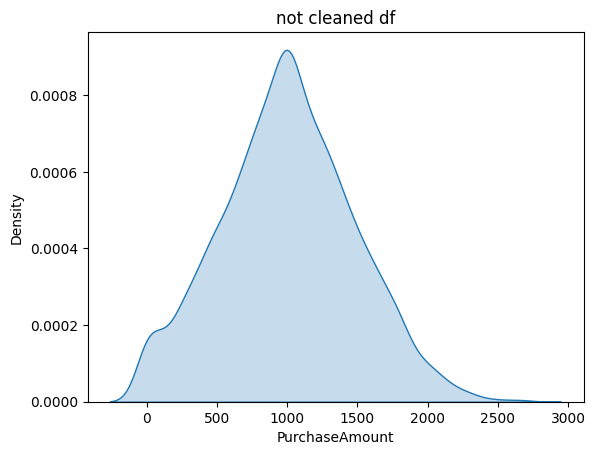

In [ ]:
#Is there any skewness or kurtosis in the PurchaseAmount distribution?
sns.kdeplot(x="PurchaseAmount",data=df,fill=True)
plt.title("not cleaned df")
plt.show()

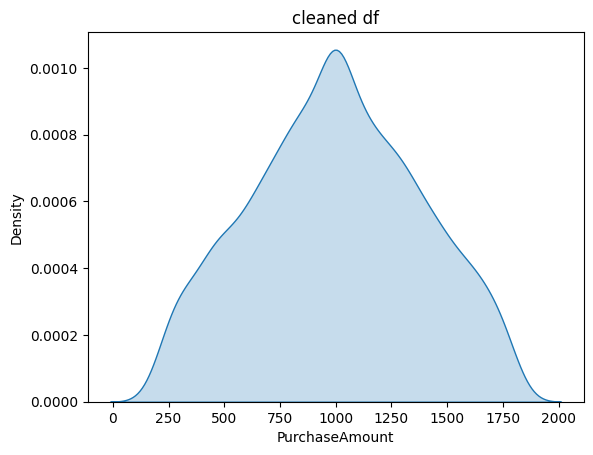

In [ ]:
sns.kdeplot(x="PurchaseAmount",data=clean_df,fill=True)
plt.title("cleaned df")
plt.show()

In [ ]:
from scipy.stats import kurtosis
from scipy.stats import skew
print("skew with outlier ", skew(df['PurchaseAmount']))
print("skew with out outlier ",skew(clean_df['PurchaseAmount']))
print("kurtosis with outlier ",kurtosis(df['PurchaseAmount']))
print("kurtosis with out outlier ",kurtosis(clean_df['PurchaseAmount']))


skew with outlier  0.10768667914138372
skew with out outlier  0.003697180237593602
kurtosis with outlier  -0.1778122600130425
kurtosis with out outlier  -0.7199313575881257


In [ ]:
# distribution has light tails if i use Percent_outliers_removal method , it remove tails

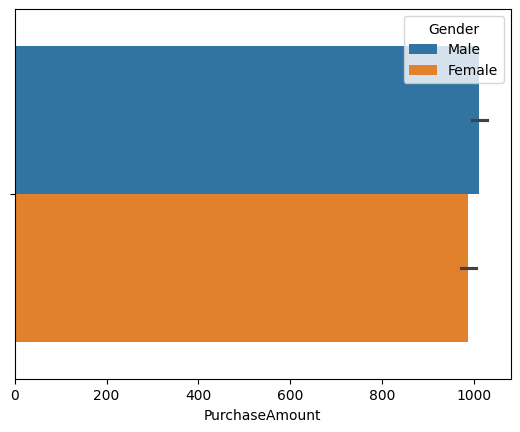

In [ ]:
#Is there a significant difference in spending between male and female customers?
sns.barplot(data=clean_df, x="PurchaseAmount", hue="Gender")
plt.show()


/tmp/ipykernel_2512/1935168645.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=clean_df,


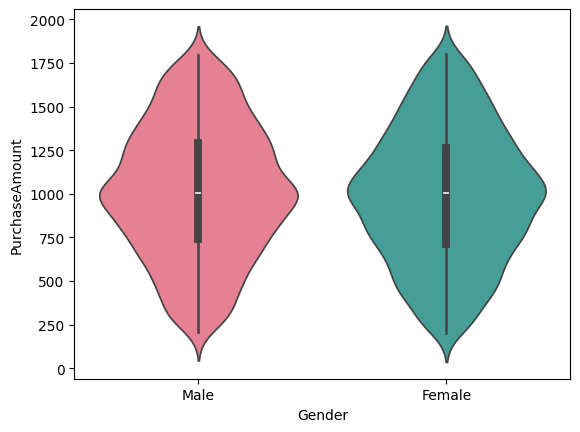

In [ ]:
sns.violinplot(data=clean_df,
               x='Gender',
               y="PurchaseAmount",
               palette='husl')

plt.show()

In [ ]:
# there Is no significant difference in spending between male and female customers

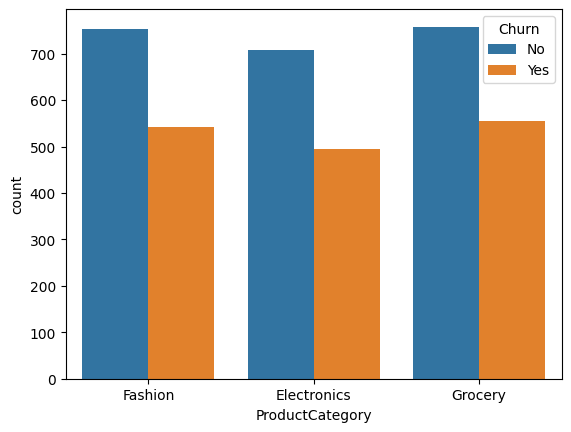

In [ ]:
# 5. Is there a relationship between ProductCategory and customer churn?
sns.countplot(data=clean_df, x="ProductCategory",hue="Churn")
plt.show()

In [ ]:
# there is no  relationship between ProductCategory and customer churn

In [ ]:
# Does PurchaseAmount vary significantly across different regions?
df['Region'] = df['Region'].ffill().bfill()
df.info()
df_sale = df.groupby("Region",as_index=False)["PurchaseAmount"].sum()
df_sale

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           5000 non-null   object 
 3   PurchaseAmount   5000 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


,Region,PurchaseAmount
0,East,1.273237e+06
1,North,1.284232e+06
2,South,1.290190e+06
3,West,1.172094e+06


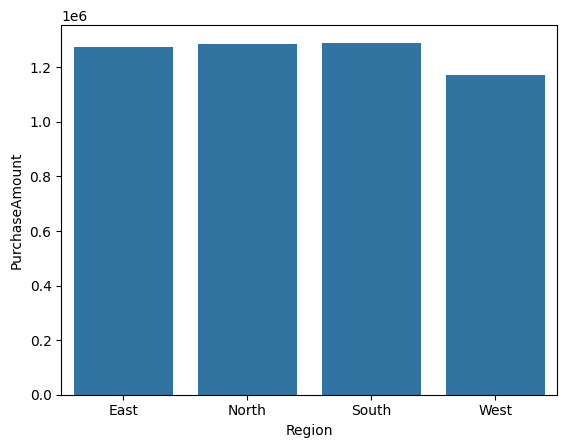

In [ ]:
sns.barplot(data=df_sale, x="Region", y="PurchaseAmount")
plt.show()


In [ ]:
#  PurchaseAmount not vary significantly across different regions

In [30]:
#Which email campaign (A or B) performed better in terms of average PurchaseAmount?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           5000 non-null   object 
 3   PurchaseAmount   5000 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [ ]:
df = df[df['CampaignGroup'].notna()]
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4815 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       4815 non-null   int64  
 1   Gender           4721 non-null   object 
 2   Region           4815 non-null   object 
 3   PurchaseAmount   4815 non-null   float64
 4   ProductCategory  4302 non-null   object 
 5   Churn            4555 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 300.9+ KB


/tmp/ipykernel_5253/2480635869.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,


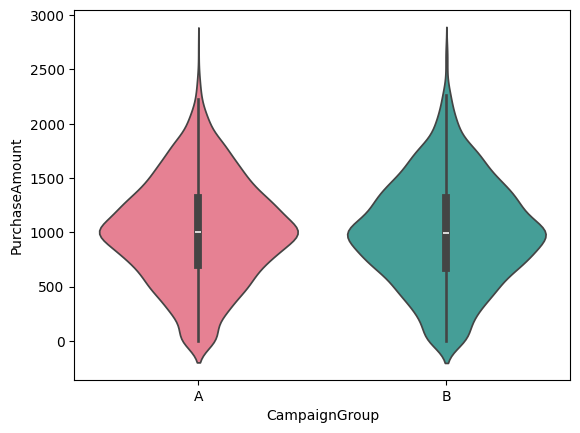

,CampaignGroup,PurchaseAmount
0,A,1011.663336
1,B,994.586394


In [ ]:
sns.violinplot(data=df,
               x='CampaignGroup',
               y="PurchaseAmount",
               palette='husl')

plt.show()
df_campain = df.groupby("CampaignGroup",as_index=False)["PurchaseAmount"].mean()
df_campain

In [ ]:
# CampaignGroup A performed better

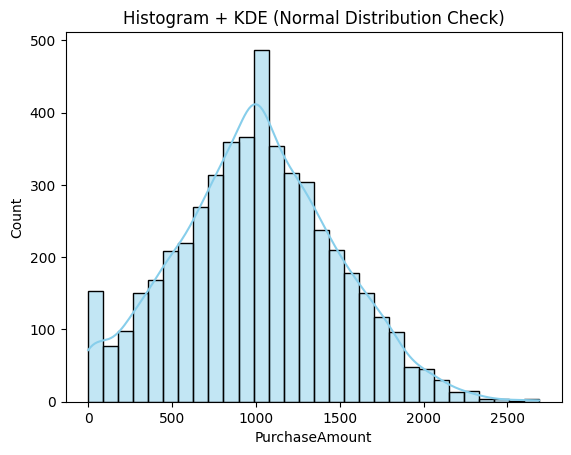

In [ ]:
#Can we assume PurchaseAmount follows a normal distribution?
sns.histplot(data=df, x="PurchaseAmount", kde=True, bins=30, color="skyblue")
plt.title("Histogram + KDE (Normal Distribution Check)")
plt.show()


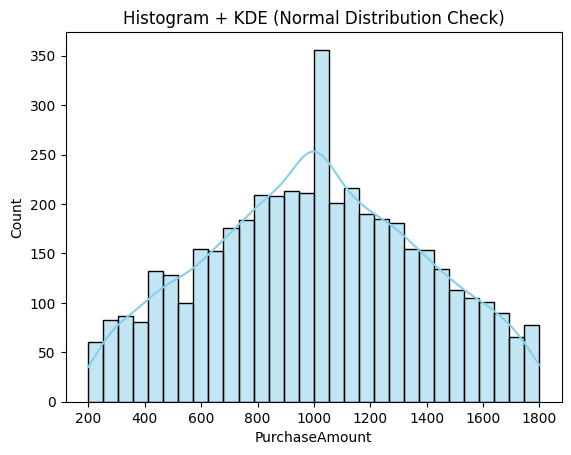

In [ ]:
sns.histplot(data=clean_df, x="PurchaseAmount", kde=True, bins=30, color="skyblue")
plt.title("Histogram + KDE (Normal Distribution Check)")
plt.show()


In [ ]:
#  data is positively skewed after cleaning it is a normal distribution?
#When you take many random samples from any population (no matter its original shape) and compute their means,
#the distribution of those sample means will tend to be normal as the sample size grows.

In [37]:
#10.What is the 95% confidence interval for the average PurchaseAmount?

import statsmodels.stats.api as sms

stats_obj = sms.DescrStatsW(df['PurchaseAmount'])

ci_low, ci_high = stats_obj.zconfint_mean(alpha=0.05)   # use z confident
(ci_low, ci_high)


(np.float64(990.7894375008099), np.float64(1017.1119027053759))

In [ ]:
# 95% confident that the average PurchaseAmount is between £990.789 and £1,017.11

In [38]:

stats_obj = sms.DescrStatsW(clean_df['PurchaseAmount'])

ci_low, ci_high = stats_obj.zconfint_mean(alpha=0.05)   # use z confident
(ci_low, ci_high)

(np.float64(989.7233064854059), np.float64(1011.9505026325786))